In [2]:
# Cell 1 - Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Cell 2 - Install libraries
# Pin numpy<2 to avoid binary-compat errors with wheels built against NumPy 1.x.
# Avoid forcing a specific torch build in Colab (GPU/CPU + CUDA must match the runtime).

!pip uninstall -y -q sentence-transformers

# Force NumPy downgrade/lock (common fix for "compiled against NumPy 1.x" errors)
!pip install -q --force-reinstall --no-cache-dir --progress-bar off numpy==1.26.4

!pip install -q --progress-bar off \
  transformers==4.40.0 \
  scikit-learn==1.4.2 \
  fairlearn==0.10.0 \
  aif360==0.6.1 \
  pandas==2.2.1 \
  matplotlib==3.8.4 \
  seaborn==0.13.2

# Verify NumPy version on disk (fresh Python process)
!python -c "import numpy as np; print('numpy (fresh proc):', np.__version__)"

# Sanity-check versions in the current kernel
import numpy as np
import torch
import transformers

print('numpy (kernel):', np.__version__)
print('torch:', torch.__version__)
print('torch.cuda.is_available():', torch.cuda.is_available())
print('transformers:', transformers.__version__)

# If torchvision/torchaudio are installed but expect a different torch version, they can spam resolver warnings.
# We don't need them for text classification, so remove them when they are clearly mismatched.
try:
    import torchvision
    tv = torchvision.__version__
except Exception:
    tv = None

try:
    import torchaudio
    ta = torchaudio.__version__
except Exception:
    ta = None

torch_v = torch.__version__

# Known pairing: torchvision 0.25.* <-> torch 2.10.* (common in recent Colab images)
if (tv and tv.startswith('0.25')) and (not torch_v.startswith('2.10')):
    print(f"Detected mismatch: torchvision=={tv} but torch=={torch_v}. Uninstalling torchvision/torchaudio to prevent conflicts.")
    !pip uninstall -y -q torchvision torchaudio

if (ta and ta.startswith('2.10')) and (not torch_v.startswith('2.10')):
    print(f"Detected mismatch: torchaudio=={ta} but torch=={torch_v}. Uninstalling torchaudio to prevent conflicts.")
    !pip uninstall -y -q torchaudio

# If the kernel still has NumPy 2.x loaded, you MUST restart the runtime/kernel.
# In Colab we can auto-restart by killing the current process.
if int(np.__version__.split('.')[0]) >= 2:
    try:
        import google.colab  # type: ignore
        print('NumPy 2.x is loaded in-kernel. Auto-restarting Colab runtime now...')
        import os
        import signal
        os.kill(os.getpid(), signal.SIGKILL)
    except Exception:
        raise RuntimeError(
            'NumPy 2.x is still loaded in this kernel. Restart the runtime/kernel, then rerun all cells from the top.'
        )

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.1 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.8.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.2

In [2]:
# Cell 3 - Unzip the files (only need to do this ONCE, first notebook only)
import os

zip_train = '/content/drive/MyDrive/jigsaw/jigsaw-unintended-bias-train.csv.zip'
zip_val   = '/content/drive/MyDrive/jigsaw/validation.csv.zip'
out_dir   = '/content/jigsaw/'

os.makedirs(out_dir, exist_ok=True)

train_csv = os.path.join(out_dir, 'jigsaw-unintended-bias-train.csv')
val_csv   = os.path.join(out_dir, 'validation.csv')

if not (os.path.exists(train_csv) and os.path.exists(val_csv)):
    !unzip -q "{zip_train}" -d "{out_dir}"
    !unzip -q "{zip_val}"   -d "{out_dir}"
else:
    print('Already extracted; skipping unzip.')

print('Files extracted:')
!ls /content/jigsaw/

Files extracted:
jigsaw-unintended-bias-train.csv  validation.csv


In [3]:
# Cell 4 - Set paths
DATA_PATH = '/content/jigsaw/jigsaw-unintended-bias-train.csv'
VAL_PATH  = '/content/jigsaw/validation.csv'

In [2]:
# Cell 5 - Part 1 reload (inside Part 3): build eval_df/train_df + datasets + load saved model
# Why: variables like `eval_df` do NOT carry over between notebooks unless you run the same kernel session.

import os
import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- 0) Resolve DATA_PATH if not set ---
if "DATA_PATH" not in globals():
    # Default Colab path used in Part 1
    DATA_PATH = "/content/jigsaw/jigsaw-unintended-bias-train.csv"

if not os.path.exists(DATA_PATH):
    raise RuntimeError(
        f"DATA_PATH not found: {DATA_PATH}. Run the unzip/path cells (Cells 1–4) or set DATA_PATH to your CSV."
    )

# --- 1) Load only needed columns and build labels ---
needed_cols = ["comment_text", "toxic", "black", "white"]
all_cols = list(pd.read_csv(DATA_PATH, nrows=0).columns)
missing = [c for c in needed_cols if c not in all_cols]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}. Available columns include: {all_cols[:50]}")

df = pd.read_csv(DATA_PATH, usecols=needed_cols)
df = df.dropna(subset=["comment_text"]).copy()
df["toxic_label"] = (df["toxic"] >= 0.5).astype(int)

# --- 2) Recreate the exact split sizes used in Part 1 (random_state=42) ---
train_df, eval_df = train_test_split(
    df,
    train_size=100_000,
    test_size=20_000,
    stratify=df["toxic_label"],
    random_state=42,
)

print("train_df:", train_df.shape, " eval_df:", eval_df.shape)

# --- 3) Tokenizer + ToxicityDataset ---
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


class ToxicityDataset(Dataset):
    def __init__(self, df_: pd.DataFrame):
        self.df = df_.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        text = str(row["comment_text"])
        label = int(row["toxic_label"])

        enc = tokenizer(
            text,
            max_length=128,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


eval_dataset = ToxicityDataset(eval_df)

# --- 4) Load saved model + THRESHOLD ---
CANDIDATE_MODEL_DIRS = [
    "/content/drive/MyDrive/rai_assignment/saved_model",
    "./saved_model",
]
MODEL_DIR = next((p for p in CANDIDATE_MODEL_DIRS if os.path.isdir(p)), None)
if MODEL_DIR is None:
    raise RuntimeError(
        "Could not find a saved model folder. Expected one of: "
        + ", ".join(CANDIDATE_MODEL_DIRS)
        + ". Run Part 1 save cell first (it creates saved_model)."
    )

print("Loading saved model from:", MODEL_DIR)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

threshold_file = os.path.join(MODEL_DIR, "threshold.txt")
if os.path.exists(threshold_file):
    with open(threshold_file, "r", encoding="utf-8") as f:
        THRESHOLD = float(f.read().strip())
else:
    THRESHOLD = 0.4

print("THRESHOLD:", THRESHOLD)

# --- 5) Create trainer (for `trainer.predict`) if possible ---
try:
    from transformers import TrainingArguments, Trainer

    args = TrainingArguments(
        output_dir="./tmp_part3",
        per_device_eval_batch_size=64,
        dataloader_drop_last=False,
        report_to="none",
    )
    trainer = Trainer(model=model, args=args)
    print("Trainer ready for predict().")
except Exception as e:
    trainer = None
    print("Warning: could not create Trainer; will use direct model inference instead.")
    print("Original error:", e)


train_df: (100000, 5)  eval_df: (20000, 5)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading saved model from: /content/drive/MyDrive/rai_assignment/saved_model
THRESHOLD: 0.4
Trainer ready for predict().


# Part 3

Start your Part 3 work below.

# Part 3 — Adversarial Attacks on a Toxicity Classifier

This section implements two attacks against the toxicity classifier trained in Part 1.

Important note about notebooks/kernels: variables like `eval_df` do **not** automatically carry over from Part 1 into Part 3.
In this notebook, **Cell 5** rebuilds `train_df` / `eval_df` from the CSV and reloads your saved model so Part 3 can run independently.

What this notebook will create/use:
- `eval_df`: DataFrame with `comment_text`, `toxic_label`, `black`, `white` (split with `random_state=42`)
- `train_df`: DataFrame with ~100,000 rows (exactly 100,000 when the CSV is available)
- `model`, `tokenizer`: reloaded from your `saved_model` folder
- `trainer`: created when `Trainer` is available; otherwise the notebook falls back to direct model inference
- `eval_dataset`: `ToxicityDataset` built from `eval_df`
- `THRESHOLD`: loaded from `threshold.txt` if present, else defaults to `0.4`

## ATTACK 1: CHARACTER-LEVEL EVASION

This attack perturbs toxic comments at the character level to evade detection while keeping the text readable to humans.

In [3]:
# STEP 1 - perturb(text): zero-width spaces + homoglyphs + random duplication

import random

ZWSP = "\u200b"  # zero-width space
HOMOGLYPHS = {
    "a": "\u0430",  # Cyrillic а
    "e": "\u0435",  # Cyrillic е
    "o": "\u043e",  # Cyrillic о
    "p": "\u0440",  # Cyrillic р
    "c": "\u0441",  # Cyrillic с
}


def _insert_zwsp_in_word(word: str) -> str:
    # Insert ZWSP between every 2-3 characters for words longer than 3 chars.
    if len(word) <= 3:
        return word

    out = []
    i = 0
    while i < len(word):
        step = random.randint(2, 3)
        out.append(word[i : i + step])
        i += step
        if i < len(word):
            out.append(ZWSP)
    return "".join(out)


def _apply_homoglyphs(text: str) -> str:
    # Replace every occurrence.
    for latin, cyr in HOMOGLYPHS.items():
        text = text.replace(latin, cyr)
    return text


def _duplicate_random_chars_in_word(word: str) -> str:
    # For each char, with 20% probability duplicate it.
    chars = []
    for ch in word:
        chars.append(ch)
        if random.random() < 0.2:
            chars.append(ch)
    return "".join(chars)


def perturb(text: str) -> str:
    # Transformation 1: ZWSP insertion per word
    words = text.split()
    words = [_insert_zwsp_in_word(w) for w in words]
    text = " ".join(words)

    # Transformation 2: homoglyph substitution on whole text
    text = _apply_homoglyphs(text)

    # Transformation 3: random char duplication per word
    words = text.split()
    words = [_duplicate_random_chars_in_word(w) for w in words]
    return " ".join(words)


In [4]:
# STEP 2 - Demonstrate perturb() on 3 toxic examples

import pandas as pd

# Pick 3 toxic comments deterministically
if "eval_df" not in globals():
    raise RuntimeError(
        "eval_df not found. In Part 3, run the Part 1 reload cell (Cell 5) first to create eval_df."
    )

examples = (
    eval_df[eval_df["toxic_label"] == 1]
    .sample(n=3, random_state=42)["comment_text"]
    .astype(str)
    .tolist()
)

print("Original vs perturbed examples (3 toxic comments):\n")
for i, orig in enumerate(examples, 1):
    pert = perturb(orig)
    print(f"Example {i}:")
    print("ORIGINAL :", orig)
    print("PERTURBED:", pert)
    print("-" * 80)


Original vs perturbed examples (3 toxic comments):

Example 1:
ORIGINAL : You don't need to study anything, except some facts. 10 minutes on Civil Beat and anyone can see that you're already master of logical fallacies, misinformation, character smears, and internet trolling.

This is what it means to disagree with anything Choon says.  You get accused of propaganda and are subject to ad hominem attacks.  I'm just a life-long resident who pays attention and cares - I just don't subscribe to the same conspiracy theory magazines as you.  People are allowed to disagree with you - it's a forum.  Stop being an internet bully.  (How are you not banned from this site already?!?!)
PERTURBED: Yоu dо​n''​t nе​ееd tо sst​ud​y аny​tth​in​gg, еx​​сее​​рt sоо​mе fа​сts​. 10 mi​nnu​tееs оn Civ​​il Bе​ааt аnd ааnnyy​оn​е саn sеее thаа​t yоu​''rrе аlr​ееаа​dy mа​sttе​r оff lоg​iсса​l fа​ll​​ас​iеs​, mmii​si​nfо​rmmа​​tiоо​n, сh​аrа​​сtе​r smmе​аr​s, аnd iin​tе​rnее​t trо​ll​inngg​. Th​is iiss whа​​t it

In [5]:
# STEP 3 - get_predictions(texts, tokenizer, model): batched softmax prob for class 1

import numpy as np
import torch


def get_predictions(texts, tokenizer, model, batch_size: int = 32):
    """Return np.ndarray of P(class=1) for each text."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    probs_pos = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = [str(t) for t in texts[i : i + batch_size]]
            enc = tokenizer(
                batch_texts,
                max_length=128,
                truncation=True,
                padding=True,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)[:, 1]
            probs_pos.append(probs.detach().cpu().numpy())

    return np.concatenate(probs_pos, axis=0)


In [6]:
# STEP 4 - Evaluation procedure: find high-confidence toxic predictions (>=0.7)

import numpy as np
import pandas as pd

if "eval_df" not in globals():
    raise RuntimeError(
        "eval_df not found. In Part 3, run the Part 1 reload cell (Cell 5) first to create eval_df/eval_dataset/model."
    )
if "eval_dataset" not in globals():
    raise RuntimeError(
        "eval_dataset not found. In Part 3, run the Part 1 reload cell (Cell 5) first."
    )
if "tokenizer" not in globals():
    raise RuntimeError(
        "tokenizer not found. In Part 3, run the Part 1 reload cell (Cell 5) first."
    )
if "THRESHOLD" not in globals():
    THRESHOLD = 0.4

# Get probabilities for full eval_dataset using trainer.predict() + softmax on logits
# Fallback: if trainer is not available, use direct model inference via get_predictions().
if "trainer" in globals() and trainer is not None:
    pred_out = trainer.predict(eval_dataset)
    logits = np.asarray(pred_out.predictions)

    # Stable softmax
    logits = logits - logits.max(axis=-1, keepdims=True)
    probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)
    probs_pos_full = probs[:, 1]
else:
    if "model" not in globals():
        raise RuntimeError("Neither trainer nor model found. Run the Part 1 reload cell (Cell 5).")
    probs_pos_full = get_predictions(
        eval_df["comment_text"].astype(str).tolist(),
        tokenizer,
        model,
        batch_size=32,
    )

# Attach to eval_df
if len(probs_pos_full) != len(eval_df):
    raise RuntimeError(
        f"Length mismatch: probs ({len(probs_pos_full)}) vs eval_df ({len(eval_df)}). "
        "Ensure eval_df and eval_dataset were built from the same split."
    )

eval_with_preds = eval_df.copy()
eval_with_preds["prob_toxic"] = probs_pos_full
eval_with_preds["pred_label"] = (eval_with_preds["prob_toxic"] >= THRESHOLD).astype(int)

# Filter: predicted toxic AND confidence >= 0.7
hc_toxic = eval_with_preds[(eval_with_preds["pred_label"] == 1) & (eval_with_preds["prob_toxic"] >= 0.7)].copy()

print("High-confidence predicted-toxic found:", len(hc_toxic))

# Sample 500 with random_state=42
n_sample = 500
if len(hc_toxic) < n_sample:
    raise RuntimeError(
        f"Only found {len(hc_toxic)} high-confidence toxic comments, need {n_sample}. "
        "Try lowering the confidence threshold (0.7) or verify model output."
    )

hc_sample = hc_toxic.sample(n=n_sample, random_state=42).copy()

print("Sampled:", len(hc_sample))
print("Sample prob_toxic summary:")
print(hc_sample["prob_toxic"].describe().to_string())


High-confidence predicted-toxic found: 1183
Sampled: 500
Sample prob_toxic summary:
count    500.000000
mean       0.915503
std        0.089350
min        0.702053
25%        0.861353
50%        0.955286
75%        0.988849
max        0.996405


In [7]:
# STEP 5 - Apply attack + measure Attack Success Rate (ASR)

import numpy as np
import pandas as pd

# Before attack
before_texts = hc_sample["comment_text"].astype(str).tolist()
before_conf = hc_sample["prob_toxic"].to_numpy()

# Apply perturbation
perturbed_texts = [perturb(t) for t in before_texts]

# Predict after attack
if "trainer" in globals() and trainer is not None:
    model_for_attack = trainer.model
elif "model" in globals():
    model_for_attack = model
else:
    raise RuntimeError("No model found for inference. Run the Part 1 reload cell (Cell 5).")

after_conf = get_predictions(perturbed_texts, tokenizer, model_for_attack, batch_size=32)
after_pred = (after_conf >= THRESHOLD).astype(int)

# Attack Success Rate: fraction of originally-toxic predictions that flip to 0
# (All 500 are predicted toxic pre-attack by construction.)
attack1_asr = float((after_pred == 0).mean())

results_table = pd.DataFrame(
    [
        {
            "Metric": "Average Confidence",
            "Before Attack": float(np.mean(before_conf)),
            "After Attack": float(np.mean(after_conf)),
        },
        {
            "Metric": "Toxic Predictions",
            "Before Attack": int(np.sum(np.ones_like(before_conf))),
            "After Attack": int(np.sum(after_pred == 1)),
        },
        {"Metric": "Attack Success Rate", "Before Attack": "-", "After Attack": f"{attack1_asr*100:.1f}%"},
    ]
)

print("Attack 1 results (500 high-confidence toxic samples):")
display(results_table) if "display" in globals() else print(results_table.to_string(index=False))


Attack 1 results (500 high-confidence toxic samples):
             Metric Before Attack After Attack
 Average Confidence      0.915503     0.015414
  Toxic Predictions           500            5
Attack Success Rate             -        99.0%


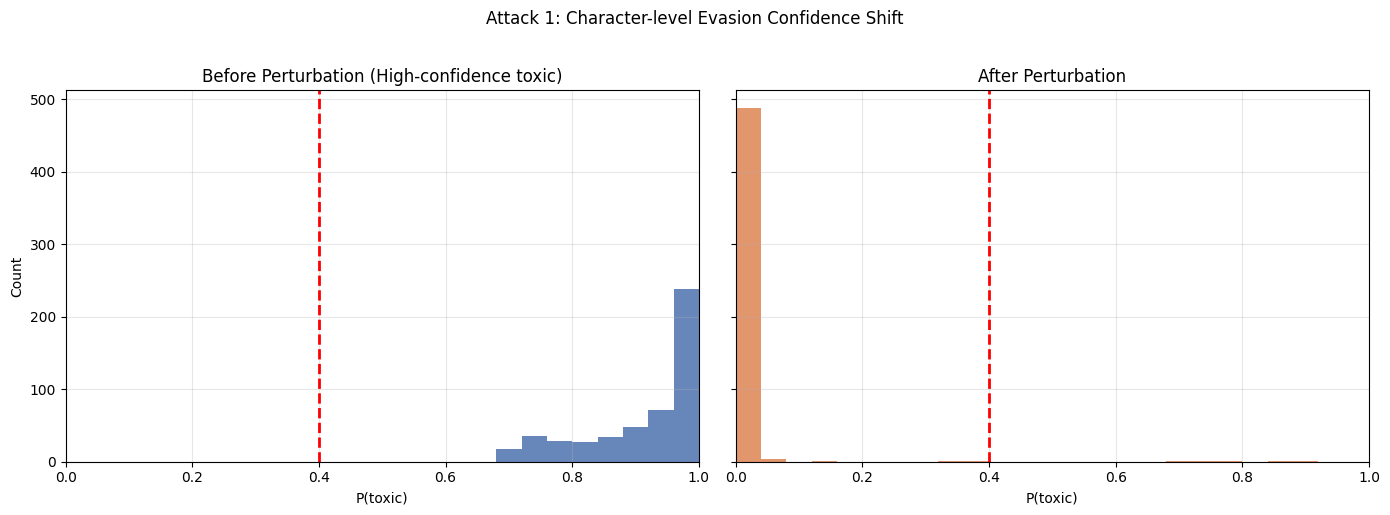

Saved: attack1_results.png


In [8]:
# STEP 6 - Visualization for Attack 1: confidence distributions before vs after

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

bins = 25

axes[0].hist(before_conf, bins=bins, range=(0, 1), color="#4C72B0", alpha=0.85)
axes[0].axvline(THRESHOLD, color="red", linestyle="--", linewidth=2)
axes[0].set_title("Before Perturbation (High-confidence toxic)")
axes[0].set_xlabel("P(toxic)")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)

axes[1].hist(after_conf, bins=bins, range=(0, 1), color="#DD8452", alpha=0.85)
axes[1].axvline(THRESHOLD, color="red", linestyle="--", linewidth=2)
axes[1].set_title("After Perturbation")
axes[1].set_xlabel("P(toxic)")
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)

fig.suptitle("Attack 1: Character-level Evasion Confidence Shift", y=1.02)
plt.tight_layout()

out_path1 = "attack1_results.png"
plt.savefig(out_path1, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path1)


## ATTACK 2: LABEL-FLIPPING POISONING

This attack poisons the training data by flipping 5% of labels, then retrains a fresh model and measures performance degradation on the *clean* evaluation set.

In [9]:
# STEP 7 - Create poisoned training data (flip exactly 5% labels)

import numpy as np
import pandas as pd

if "train_df" not in globals():
    raise RuntimeError("train_df not found. Run your Part 1 reload cells first.")

if len(train_df) != 100_000:
    print(f"Warning: train_df has {len(train_df):,} rows (expected 100,000). Proceeding anyway.")

poisoned_train_df = train_df.copy()

# Select exactly 5% rows with random_state=42
n_poison = int(round(len(poisoned_train_df) * 0.05))
# Requirement says exactly 5,000 when train_df=100,000
if len(poisoned_train_df) == 100_000:
    n_poison = 5_000

poison_idx = poisoned_train_df.sample(n=n_poison, random_state=42).index

before_labels = poisoned_train_df.loc[poison_idx, "toxic_label"].astype(int)

# Flip labels
poisoned_train_df.loc[poison_idx, "toxic_label"] = 1 - before_labels

after_labels = poisoned_train_df.loc[poison_idx, "toxic_label"].astype(int)

n_toxic_to_nontoxic = int(((before_labels == 1) & (after_labels == 0)).sum())
n_nontoxic_to_toxic = int(((before_labels == 0) & (after_labels == 1)).sum())

print("Poisoning summary (5% label flip):")
print("- Selected rows:", n_poison)
print("- toxic -> nontoxic flips:", n_toxic_to_nontoxic)
print("- nontoxic -> toxic flips:", n_nontoxic_to_toxic)

print("\nClass distribution BEFORE poisoning:")
print(train_df["toxic_label"].value_counts(normalize=True).rename("proportion").to_string())

print("\nClass distribution AFTER poisoning:")
print(poisoned_train_df["toxic_label"].value_counts(normalize=True).rename("proportion").to_string())


Poisoning summary (5% label flip):
- Selected rows: 5000
- toxic -> nontoxic flips: 439
- nontoxic -> toxic flips: 4561

Class distribution BEFORE poisoning:
toxic_label
0    0.92003
1    0.07997

Class distribution AFTER poisoning:
toxic_label
0    0.87881
1    0.12119


In [10]:
# STEP 8 - Retrain a fresh model on poisoned data and save it

import os
import torch

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Disable W&B logging prompts if present
os.environ["WANDB_DISABLED"] = "true"

# Ensure ToxicityDataset exists; if not, define a minimal compatible version.
if "ToxicityDataset" not in globals():
    from torch.utils.data import Dataset

    class ToxicityDataset(Dataset):
        def __init__(self, df):
            self.df = df.reset_index(drop=True)

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            text = str(row["comment_text"])
            label = int(row["toxic_label"])
            enc = tokenizer(
                text,
                max_length=128,
                truncation=True,
                padding="max_length",
                return_tensors="pt",
            )
            return {
                "input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(label, dtype=torch.long),
            }


poisoned_train_dataset = ToxicityDataset(poisoned_train_df)

# Fresh model from original pretrained checkpoint (NOT from saved_model)
poisoned_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
)

training_args_poisoned = TrainingArguments(
    output_dir="./poisoned_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    logging_steps=200,
    report_to="none",
)

poisoned_trainer = Trainer(
    model=poisoned_model,
    args=training_args_poisoned,
    train_dataset=poisoned_train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
)

poisoned_trainer.train()

# Save poisoned model
poisoned_out_dir = "./poisoned_model"
poisoned_trainer.model.save_pretrained(poisoned_out_dir)
tokenizer.save_pretrained(poisoned_out_dir)

print("Saved poisoned model to:", poisoned_out_dir)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.286700,0.170746
2,0.267300,0.164731
3,0.226600,0.176362


Saved poisoned model to: ./poisoned_model


In [11]:
# STEP 9 - Evaluate poisoned model on CLEAN eval_dataset

import numpy as np
from sklearn.metrics import accuracy_score, f1_score


def _softmax_prob_pos_from_trainer(trainer_obj, dataset_obj):
    pred_out = trainer_obj.predict(dataset_obj)
    logits = np.asarray(pred_out.predictions)
    logits = logits - logits.max(axis=-1, keepdims=True)
    probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)
    return probs[:, 1]


def _metrics_at_threshold(y_true, prob_pos, threshold: float):
    y_pred = (prob_pos >= threshold).astype(int)
    acc = float(accuracy_score(y_true, y_pred))
    f1 = float(f1_score(y_true, y_pred, average="macro"))

    # FNR = FN / (TP + FN)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tpr = (tp / (tp + fn)) if (tp + fn) else 0.0
    fnr = (fn / (tp + fn)) if (tp + fn) else 0.0

    return {
        "Accuracy": acc,
        "Macro F1": f1,
        "TPR": float(tpr),
        "FNR": float(fnr),
    }


y_true_eval = eval_df["toxic_label"].astype(int).to_numpy()

# Clean model baseline (from Part 1 trainer)
clean_prob_pos = _softmax_prob_pos_from_trainer(trainer, eval_dataset)
clean_metrics = _metrics_at_threshold(y_true_eval, clean_prob_pos, THRESHOLD)

# Poisoned model
poisoned_prob_pos = _softmax_prob_pos_from_trainer(poisoned_trainer, eval_dataset)
poisoned_metrics = _metrics_at_threshold(y_true_eval, poisoned_prob_pos, THRESHOLD)

print("Clean model metrics @ THRESHOLD=0.4:")
print(clean_metrics)

print("\nPoisoned model metrics @ THRESHOLD=0.4:")
print(poisoned_metrics)


Clean model metrics @ THRESHOLD=0.4:
{'Accuracy': 0.94125, 'Macro F1': 0.8077097916244294, 'TPR': 0.6747967479674797, 'FNR': 0.3252032520325203}

Poisoned model metrics @ THRESHOLD=0.4:
{'Accuracy': 0.9409, 'Macro F1': 0.7990233145197392, 'TPR': 0.6297686053783614, 'FNR': 0.3702313946216385}


In [12]:
# STEP 10 - Before/after comparison table (Clean vs Poisoned)

import pandas as pd

rows = []
for metric in ["Accuracy", "Macro F1", "FNR", "TPR"]:
    clean_v = float(clean_metrics[metric])
    poison_v = float(poisoned_metrics[metric])
    delta = poison_v - clean_v
    rows.append(
        {
            "Metric": metric,
            "Clean Model": clean_v,
            "Poisoned Model": poison_v,
            "Change": delta,
        }
    )

compare_df = pd.DataFrame(rows)

# Highlight which metric changed the most (absolute change)
compare_df["AbsChange"] = compare_df["Change"].abs()
max_row = compare_df.loc[compare_df["AbsChange"].idxmax()]
max_metric = max_row["Metric"]

compare_df = compare_df.drop(columns=["AbsChange"])

print("Clean vs Poisoned comparison (@ THRESHOLD=0.4):")
try:
    from IPython.display import display

    display(compare_df.style.format({"Clean Model": "{:.4f}", "Poisoned Model": "{:.4f}", "Change": "{:+.4f}"}))
except Exception:
    print(compare_df.to_string(index=False))

print("\nMetric with largest change:", max_metric)


Clean vs Poisoned comparison (@ THRESHOLD=0.4):


,Metric,Clean Model,Poisoned Model,Change
0,Accuracy,0.9413,0.9409,-0.0004
1,Macro F1,0.8077,0.7990,-0.0087
2,FNR,0.3252,0.3702,+0.0450
3,TPR,0.6748,0.6298,-0.0450



Metric with largest change: TPR


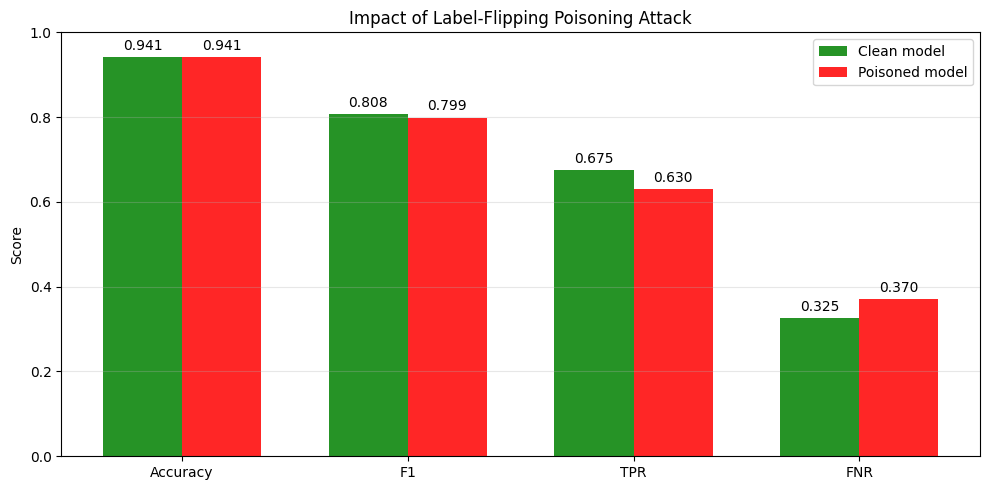

Saved: attack2_results.png


In [13]:
# STEP 11 - Visualization for Attack 2: grouped bar chart (Clean vs Poisoned)

import matplotlib.pyplot as plt
import numpy as np

metrics_order = ["Accuracy", "Macro F1", "TPR", "FNR"]
clean_vals = [float(clean_metrics[m]) for m in metrics_order]
poison_vals = [float(poisoned_metrics[m]) for m in metrics_order]

x = np.arange(len(metrics_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width / 2, clean_vals, width, label="Clean model", color="green", alpha=0.85)
bars2 = ax.bar(x + width / 2, poison_vals, width, label="Poisoned model", color="red", alpha=0.85)

ax.set_title("Impact of Label-Flipping Poisoning Attack")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "F1", "TPR", "FNR"])
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

# Value labels
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)

plt.tight_layout()

out_path2 = "attack2_results.png"
plt.savefig(out_path2, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path2)


In [14]:
# STEP 12 - Markdown analysis cell (auto-filled with your computed results)

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

# Pull numbers from computed results
asr_pct = attack1_asr * 100.0
fnr_clean = float(clean_metrics["FNR"])
fnr_poisoned = float(poisoned_metrics["FNR"])
fnr_increase = fnr_poisoned - fnr_clean

acc_clean = float(clean_metrics["Accuracy"])
acc_poisoned = float(poisoned_metrics["Accuracy"])

f1_clean = float(clean_metrics["Macro F1"])
f1_poisoned = float(poisoned_metrics["Macro F1"])

tpr_clean = float(clean_metrics["TPR"])
tpr_poisoned = float(poisoned_metrics["TPR"])

# Decide which metric changed most (absolute)
deltas = {
    "Accuracy": acc_poisoned - acc_clean,
    "Macro F1": f1_poisoned - f1_clean,
    "TPR": tpr_poisoned - tpr_clean,
    "FNR": fnr_poisoned - fnr_clean,
}
worst_metric = max(deltas, key=lambda k: abs(deltas[k]))

analysis_md = f"""
## Markdown Analysis (Adversarial Attacks)

### Question 1: Which attack was more effective numerically?
- **Attack 1 (Character-level evasion)** — Attack Success Rate (ASR): **{asr_pct:.1f}%** of the 500 high-confidence toxic comments flipped to non-toxic after perturbation.
- **Attack 2 (Label-flipping poisoning)** — False Negative Rate (FNR) increased from **{fnr_clean:.4f}** to **{fnr_poisoned:.4f}** (Δ **{fnr_increase:+.4f}**).

**Interpretation:**
- Attack 1 is highly effective at **per-comment evasion** when an attacker can modify text.
- Attack 2 causes **systemic performance damage** on clean data; the largest absolute change was in **{worst_metric}** (Δ **{deltas[worst_metric]:+.4f}**).

### Question 2: Which attack is more operationally dangerous for a live platform and why?
- **Attack 1** is realistic for everyday users: it only requires manual effort per comment (e.g., inserting zero-width characters / homoglyphs). This makes it a common *evasion* threat.
- **Attack 2** requires influence over the training pipeline (data collection, labeling, ingestion, or model training). That’s a stronger adversary model (insider risk, compromised labeling vendor, or poisoning via feedback loops).

For most social media platforms, **Attack 1 is the more realistic day-to-day threat**, while **Attack 2 is the higher-impact but higher-access threat** (less frequent but more damaging if it occurs).

### Question 3: Where should defenses be prioritized?
- **Defenses for Attack 1 (input-time):**
  - Unicode normalization (e.g., NFKC),
  - strip/replace zero-width characters (including U+200B),
  - map known homoglyphs back to Latin,
  - optionally run character-level spell/noise normalization.
- **Defenses for Attack 2 (training-time):**
  - strong data provenance + signed data pipelines,
  - label anomaly detection (sudden flips, annotator drift),
  - robust training (noise-robust loss, audit samples),
  - quarantining high-risk sources.

**Priority recommendation:** prioritize **input preprocessing** for immediate robustness against widespread evasion, and invest in **training pipeline integrity** as a critical second line because poisoning can silently degrade the model and increase harmful misses (here, FNR increased by **{fnr_increase:+.4f}**).
"""

if display is not None and Markdown is not None:
    display(Markdown(analysis_md))
else:
    print(analysis_md)



## Markdown Analysis (Adversarial Attacks)

### Question 1: Which attack was more effective numerically?
- **Attack 1 (Character-level evasion)** — Attack Success Rate (ASR): **99.0%** of the 500 high-confidence toxic comments flipped to non-toxic after perturbation.
- **Attack 2 (Label-flipping poisoning)** — False Negative Rate (FNR) increased from **0.3252** to **0.3702** (Δ **+0.0450**).

**Interpretation:**
- Attack 1 is highly effective at **per-comment evasion** when an attacker can modify text.
- Attack 2 causes **systemic performance damage** on clean data; the largest absolute change was in **TPR** (Δ **-0.0450**).

### Question 2: Which attack is more operationally dangerous for a live platform and why?
- **Attack 1** is realistic for everyday users: it only requires manual effort per comment (e.g., inserting zero-width characters / homoglyphs). This makes it a common *evasion* threat.
- **Attack 2** requires influence over the training pipeline (data collection, labeling, ingestion, or model training). That’s a stronger adversary model (insider risk, compromised labeling vendor, or poisoning via feedback loops).

For most social media platforms, **Attack 1 is the more realistic day-to-day threat**, while **Attack 2 is the higher-impact but higher-access threat** (less frequent but more damaging if it occurs).

### Question 3: Where should defenses be prioritized?
- **Defenses for Attack 1 (input-time):**
  - Unicode normalization (e.g., NFKC),
  - strip/replace zero-width characters (including U+200B),
  - map known homoglyphs back to Latin,
  - optionally run character-level spell/noise normalization.
- **Defenses for Attack 2 (training-time):**
  - strong data provenance + signed data pipelines,
  - label anomaly detection (sudden flips, annotator drift),
  - robust training (noise-robust loss, audit samples),
  - quarantining high-risk sources.

**Priority recommendation:** prioritize **input preprocessing** for immediate robustness against widespread evasion, and invest in **training pipeline integrity** as a critical second line because poisoning can silently degrade the model and increase harmful misses (here, FNR increased by **+0.0450**).
